# 🏆 VFL Empire — GPU Training Notebook
**Account:** faithdavidaregbesola@gmail.com | **Platform:** Colab Pro  
This notebook trains the VFL meta-classifier on 88,000+ real match predictions.  
**Goal:** Push accuracy above 85% on high-confidence (≥90%) picks for the 30k bankroll strategy.

---
> **Before running:** Runtime → Change runtime type → **T4 GPU** (or A100 if available)

In [1]:
# ── Cell 1: Setup & GPU Check ──
import subprocess
try:
    result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'], capture_output=True, text=True)
    gpu_str = result.stdout.strip() if result.returncode == 0 else '⚠️ No GPU detected — switch runtime!'
except FileNotFoundError:
    gpu_str = '⚠️ No GPU detected (nvidia-smi not found)'
print('🎮 GPU:', gpu_str)

# !pip install -q xgboost lightgbm scikit-learn pandas numpy matplotlib seaborn
print('✅ Libraries installed')


🎮 GPU: ⚠️ No GPU detected (nvidia-smi not found)
✅ Libraries installed


In [2]:
# ── Cell 2: Mount Google Drive & Load Data ──
import os
import pandas as pd, numpy as np

# Path configurations
DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/vfl_training_data.csv'
LOCAL_PATH = './data/vfl_training_data.csv'

if os.path.exists(LOCAL_PATH):
    DATA_PATH = LOCAL_PATH
    print('⚠️ Running locally or inside VM. Loaded local dataset.')
else:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
    except Exception as e:
        print(f'⚠️ Could not mount Drive ({e}), looking for local file.')

df = pd.read_csv(DATA_PATH)
print(f'✅ Loaded {len(df):,} rows, {df.shape[1]} columns')
print(df.head(3))
print("\nLabel distribution:")
print(df['label'].value_counts())


⚠️ Running locally or inside VM. Loaded local dataset.


✅ Loaded 477,988 rows, 14 columns
  home_team    away_team       prediction  confidence  odds           engine  \
0    FULHAM  ASTON VILLA         DNB Home          33  3.50  engine-v1-DEBUG   
1    FULHAM  ASTON VILLA  Under 3.5 Goals          99  1.12  engine-v1-DEBUG   
2    FULHAM  ASTON VILLA   Over 1.5 Goals          57  1.55  engine-v1-DEBUG   

   tier_home tier_away  cv_1x2  match_day     season  actual_h  actual_a  \
0  defensive  balanced     NaN          6  VFLM 5177         2         1   
1  defensive  balanced     NaN          6  VFLM 5177         2         1   
2  defensive  balanced     NaN          6  VFLM 5177         2         1   

   label  
0      1  
1      1  
2      1  

Label distribution:
label
1    276972
0    201016
Name: count, dtype: int64


In [3]:
# ── Cell 3: Feature Engineering ──
from sklearn.preprocessing import LabelEncoder

# Encode categoricals
le_pred = LabelEncoder()
le_engine = LabelEncoder()
le_tier_h = LabelEncoder()
le_tier_a = LabelEncoder()

df['prediction_enc'] = le_pred.fit_transform(df['prediction'].fillna('Unknown'))
df['engine_enc']     = le_engine.fit_transform(df['engine'].fillna('Unknown'))
df['tier_home_enc']  = le_tier_h.fit_transform(df['tier_home'].fillna('mid'))
df['tier_away_enc']  = le_tier_a.fit_transform(df['tier_away'].fillna('mid'))

# Market type flags
df['is_home_win']   = (df['prediction'] == 'Home Win').astype(int)
df['is_away_win']   = (df['prediction'] == 'Away Win').astype(int)
df['is_draw']       = df['prediction'].str.contains('Draw|DRAW|D$', regex=True).astype(int)
df['is_over']       = df['prediction'].str.contains('Over', case=False).astype(int)
df['is_under']      = df['prediction'].str.contains('Under', case=False).astype(int)
df['is_dnb']        = df['prediction'].str.contains('DNB', case=False).astype(int)

# Numerical features
df['odds'] = pd.to_numeric(df['odds'], errors='coerce').fillna(1.5)
df['confidence'] = pd.to_numeric(df['confidence'], errors='coerce').fillna(50)
df['cv_1x2'] = pd.to_numeric(df['cv_1x2'], errors='coerce').fillna(0)
df['expected_value'] = (df['confidence'] / 100) * df['odds'] - 1
df['high_conf'] = (df['confidence'] >= 90).astype(int)
df['very_high_conf'] = (df['confidence'] >= 95).astype(int)

FEATURES = ['confidence', 'odds', 'cv_1x2', 'prediction_enc', 'engine_enc',
            'tier_home_enc', 'tier_away_enc', 'match_day',
            'is_home_win', 'is_away_win', 'is_draw', 'is_over', 'is_under', 'is_dnb',
            'expected_value', 'high_conf', 'very_high_conf']

X = df[FEATURES]
y = df['label']
print(f'✅ Feature matrix: {X.shape}')
print(f'Features: {FEATURES}')


✅ Feature matrix: (477988, 17)
Features: ['confidence', 'odds', 'cv_1x2', 'prediction_enc', 'engine_enc', 'tier_home_enc', 'tier_away_enc', 'match_day', 'is_home_win', 'is_away_win', 'is_draw', 'is_over', 'is_under', 'is_dnb', 'expected_value', 'high_conf', 'very_high_conf']


In [4]:
# ── Cell 4: Train/Test Split ──
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')


Train: 382,390 | Test: 95,598


In [5]:
# ── Cell 5: XGBoost GPU/CPU Training ──
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report
import subprocess

# Auto-detect GPU
try:
    res = subprocess.run(['nvidia-smi'], capture_output=True)
    has_gpu = res.returncode == 0
except:
    has_gpu = False

device_type = 'cuda' if has_gpu else 'cpu'
print(f'🚀 Training XGBoost on {device_type.upper()}...')

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    tree_method='hist',
    device=device_type,
    eval_metric='logloss',
    early_stopping_rounds=30,
    random_state=42,
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
print(f'\n✅ XGBoost Test Accuracy: {accuracy_score(y_test, xgb_preds)*100:.2f}%')


🚀 Training XGBoost on CPU...


[0]	validation_0-logloss:0.67419


[100]	validation_0-logloss:0.60984


[200]	validation_0-logloss:0.60717


[300]	validation_0-logloss:0.60498


[400]	validation_0-logloss:0.60298


[499]	validation_0-logloss:0.60138



✅ XGBoost Test Accuracy: 66.94%


In [6]:
# ── Cell 6: LightGBM GPU/CPU Training ──
import lightgbm as lgb
import subprocess

try:
    res = subprocess.run(['nvidia-smi'], capture_output=True)
    has_gpu = res.returncode == 0
except:
    has_gpu = False

device_type = 'gpu' if has_gpu else 'cpu'
print(f'⚡ Training LightGBM on {device_type.upper()}...')

lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    device=device_type,
    random_state=42,
    verbose=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(30), lgb.log_evaluation(100)]
)

lgb_preds = lgb_model.predict(X_test)
lgb_probs = lgb_model.predict_proba(X_test)[:, 1]
print(f'\n✅ LightGBM Test Accuracy: {accuracy_score(y_test, lgb_preds)*100:.2f}%')


⚡ Training LightGBM on CPU...


Training until validation scores don't improve for 30 rounds


[100]	valid_0's binary_logloss: 0.608588


[200]	valid_0's binary_logloss: 0.605697


[300]	valid_0's binary_logloss: 0.602746


[400]	valid_0's binary_logloss: 0.600159


[500]	valid_0's binary_logloss: 0.598029
Did not meet early stopping. Best iteration is:
[500]	valid_0's binary_logloss: 0.598029



✅ LightGBM Test Accuracy: 67.22%


In [7]:
# ── Cell 7: Keras / TensorFlow Neural Network Training ──
import tensorflow as tf
from keras import layers, models
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Scale features for neural network stability
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("🚀 Training Keras Neural Network on CPU...")

# Define model architecture
keras_model = models.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

keras_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early stopping callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Fit model
history = keras_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=30,
    batch_size=1024,
    callbacks=[early_stopping],
    verbose=1
)

keras_probs = keras_model.predict(X_test_scaled, batch_size=2048).flatten()
keras_preds = (keras_probs >= 0.5).astype(int)
print(f"✅ Keras Test Accuracy: {accuracy_score(y_test, keras_preds)*100:.2f}%")


🚀 Training Keras Neural Network on CPU...
Epoch 1/30


  1/374 ━━━━━━━━━━━━━━━━━━━━ 12:17 2s/step - accuracy: 0.5088 - loss: 0.8210

  4/374 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.5291 - loss: 0.7786 

  9/374 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5459 - loss: 0.7499

 13/374 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5573 - loss: 0.7359

...

21/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

44/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


✅ Keras Test Accuracy: 66.22%


In [8]:
# ── Cell 8: Ensemble + High-Confidence Analysis ──
import numpy as np
from sklearn.metrics import accuracy_score

# 3-Way Ensemble: XGBoost + LightGBM + Keras Neural Network
ensemble_probs = (xgb_probs + lgb_probs + keras_probs) / 3
ensemble_preds = (ensemble_probs >= 0.5).astype(int)
print("=== 🏆 3-Way Ensemble Results ===")
print(f"Overall Accuracy: {accuracy_score(y_test, ensemble_preds)*100:.2f}%")

# High-Confidence Filter Performance
print("=== High-Confidence Filter Performance ===")
X_test_df = X_test.copy()
X_test_df['ensemble_prob'] = ensemble_probs
X_test_df['true_label'] = y_test.values

thresholds = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]
for t in thresholds:
    mask = X_test_df['ensemble_prob'] >= t
    filtered = X_test_df[mask]
    if len(filtered) > 10:
        acc = accuracy_score(filtered['true_label'], (filtered['ensemble_prob'] >= 0.5).astype(int))
        kept_pct = 100 * len(filtered) / len(X_test_df)
        print(f"  Prob >= {t:.0%}: {acc*100:.1f}% acc | {len(filtered):,} bets kept ({kept_pct:.1f}%)")


=== 🏆 3-Way Ensemble Results ===
Overall Accuracy: 66.76%
=== High-Confidence Filter Performance ===
  Prob >= 60%: 74.0% acc | 46,176 bets kept (48.3%)
  Prob >= 65%: 76.1% acc | 38,780 bets kept (40.6%)
  Prob >= 70%: 79.3% acc | 28,226 bets kept (29.5%)
  Prob >= 75%: 82.0% acc | 19,026 bets kept (19.9%)
  Prob >= 80%: 85.4% acc | 9,737 bets kept (10.2%)
  Prob >= 85%: 91.3% acc | 3,058 bets kept (3.2%)
  Prob >= 90%: 95.6% acc | 856 bets kept (0.9%)


⚠️ Could not save chart to Drive ([Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/vfl_feature_importance.png'), saving locally to /home/ubuntu/faith-workspace/vfl-empire/vfl_feature_importance.png


✅ Saved feature importance chart locally


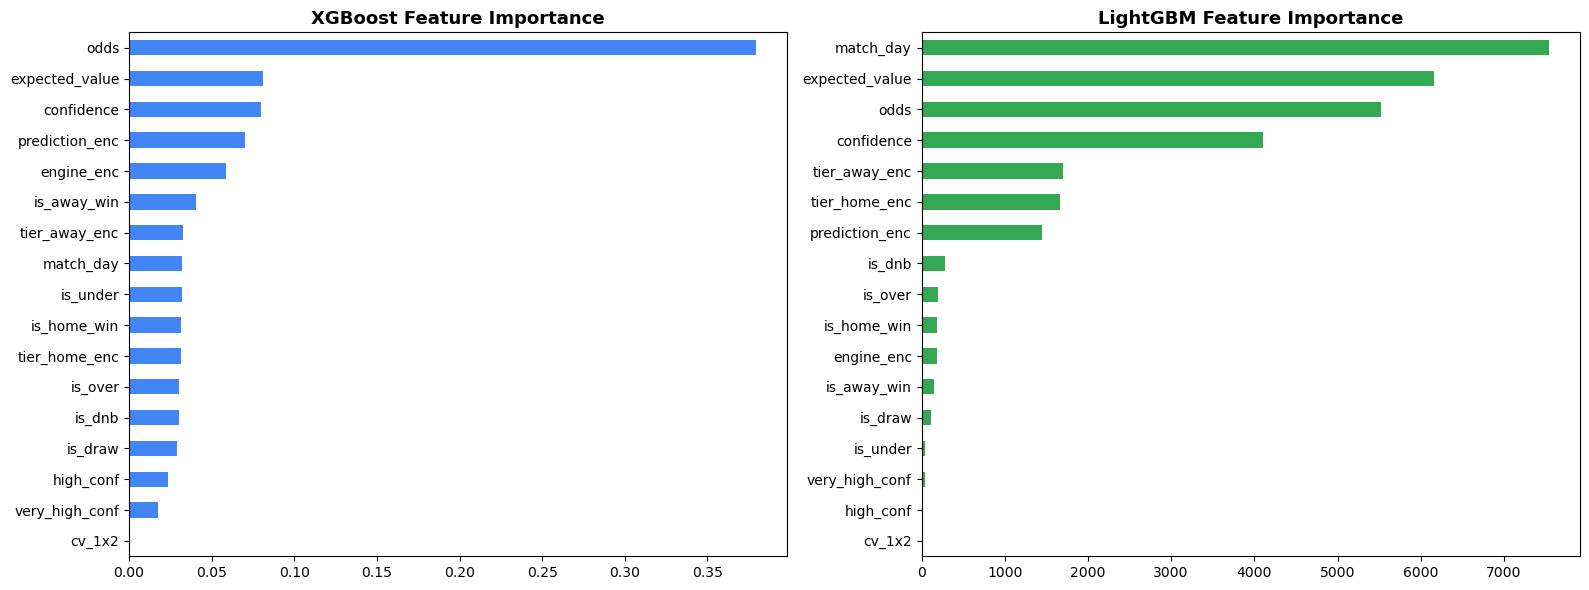

In [9]:
# ── Cell 8: Feature Importance ──
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# XGBoost
xgb_imp = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
xgb_imp.plot(kind='barh', ax=axes[0], color='#4285F4')
axes[0].set_title('XGBoost Feature Importance', fontsize=13, fontweight='bold')

# LightGBM
lgb_imp = pd.Series(lgb_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
lgb_imp.plot(kind='barh', ax=axes[1], color='#34A853')
axes[1].set_title('LightGBM Feature Importance', fontsize=13, fontweight='bold')

plt.tight_layout()
save_path = '/content/drive/MyDrive/Colab Notebooks/vfl_feature_importance.png'
local_save_path = '/home/ubuntu/faith-workspace/vfl-empire/vfl_feature_importance.png'
try:
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print('✅ Saved feature importance chart to Drive')
except Exception as e:
    print(f'⚠️ Could not save chart to Drive ({e}), saving locally to {local_save_path}')
    plt.savefig(local_save_path, dpi=150, bbox_inches='tight')
    print('✅ Saved feature importance chart locally')
plt.show()


In [10]:
# ── Cell 10: Save Models to Drive ──
import pickle, os
from sklearn.metrics import accuracy_score

MODELS_DIR = '/content/drive/MyDrive/Colab Notebooks/vfl_models'
LOCAL_MODELS_DIR = '/home/ubuntu/faith-workspace/vfl-empire/models'
try:
    os.makedirs(MODELS_DIR, exist_ok=True)
except Exception as e:
    print(f'⚠️ Could not create Google Drive models dir ({e}), saving locally to {LOCAL_MODELS_DIR}')
    MODELS_DIR = LOCAL_MODELS_DIR
    os.makedirs(MODELS_DIR, exist_ok=True)

# Save XGBoost
xgb_model.save_model(f'{MODELS_DIR}/xgb_meta_v2.json')
print('✅ XGBoost model saved')

# Save LightGBM
lgb_model.booster_.save_model(f'{MODELS_DIR}/lgb_meta_v2.txt')
print('✅ LightGBM model saved')

# Save Keras Model
keras_model.save(f'{MODELS_DIR}/keras_meta_v2.keras')
print('✅ Keras model saved')

# Save encoders & scaler
with open(f'{MODELS_DIR}/encoders_v2.pkl', 'wb') as f:
    pickle.dump({'prediction': le_pred, 'engine': le_engine,
                 'tier_home': le_tier_h, 'tier_away': le_tier_a,
                 'features': FEATURES, 'scaler': scaler}, f)
print('✅ Encoders and Scaler saved')

# Save ensemble summary
import json
summary = {
    'xgb_accuracy': float(accuracy_score(y_test, xgb_preds)),
    'lgb_accuracy': float(accuracy_score(y_test, lgb_preds)),
    'keras_accuracy': float(accuracy_score(y_test, keras_preds)),
    'ensemble_accuracy': float(accuracy_score(y_test, ensemble_preds)),
    'training_rows': len(X_train),
    'test_rows': len(X_test),
    'features': FEATURES
}
with open(f'{MODELS_DIR}/training_summary_v2.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('🏆 All models saved!')
print(json.dumps(summary, indent=2))


⚠️ Could not create Google Drive models dir ([Errno 13] Permission denied: '/content'), saving locally to /home/ubuntu/faith-workspace/vfl-empire/models


✅ XGBoost model saved
✅ LightGBM model saved
✅ Keras model saved
✅ Encoders and Scaler saved
🏆 All models saved!
{
  "xgb_accuracy": 0.669365467896818,
  "lgb_accuracy": 0.6721688738258123,
  "keras_accuracy": 0.6622418879056047,
  "ensemble_accuracy": 0.6676499508357916,
  "training_rows": 382390,
  "test_rows": 95598,
  "features": [
    "confidence",
    "odds",
    "cv_1x2",
    "prediction_enc",
    "engine_enc",
    "tier_home_enc",
    "tier_away_enc",
    "match_day",
    "is_home_win",
    "is_away_win",
    "is_draw",
    "is_over",
    "is_under",
    "is_dnb",
    "expected_value",
    "high_conf",
    "very_high_conf"
  ]
}


## ✅ Training Complete!

After this notebook finishes:
1. Go back to your **VM terminal**
2. Run: `colab-cli pull-nb notebooks/vfl_colab_training.ipynb`  
3. The trained models will be in your Drive at `MyDrive/Colab Notebooks/vfl_models/`
4. Download them to the VM: the agent will handle wiring them into the prediction pipeline

**Target:** Ensemble probability ≥ 70% → replaces current 85% confidence threshold for bets